# Notebook 09 — Special Font OCR with Gemma 4

Extract text and structured fields from scanned Hebrew PDF pages that use a non-standard font.
Uses **Gemma 4 26B-A4B-it (4-bit, MLX)** running locally on Apple Silicon.

**Environment (MANDATORY):** `doc-risk-classifier` pyenv (Python 3.13.11)
```bash
pyenv activate doc-risk-classifier
```

## Pipeline
1. Read the page manifest produced by `scripts/split_pdfs_to_pages.py`
2. Load Gemma 4 via `mlx-vlm`
3. Run full OCR on each page (extract all visible text)
4. Run structured field extraction on each page (JSON output)
5. Aggregate and export results

## 1 — Setup

Install `mlx-vlm` if not already present (requires `doc-risk-classifier` pyenv):

In [1]:
# Run once to install mlx-vlm into the doc-risk-classifier environment
import subprocess, sys
env_python = sys.executable
result = subprocess.run(
    [env_python, "-m", "pip", "install", "-q", "-U", "mlx-vlm"],
    capture_output=True, text=True
)
if result.returncode != 0:
    print(result.stderr)
else:
    print("mlx-vlm ready")

mlx-vlm ready


In [2]:
import json
import sys
import time
from pathlib import Path

import mlx_vlm
import pandas as pd
from tqdm.notebook import tqdm
from mlx_vlm import load, generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

print(f"Python  : {sys.version}")
print(f"mlx-vlm : {mlx_vlm.__version__}")

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT         = Path(".").resolve().parent
PAGES_DIR    = ROOT / "data" / "spaciel_font_pages"
MANIFEST_CSV = PAGES_DIR / "manifest.csv"
RESULTS_CSV  = PAGES_DIR / "ocr_results.csv"
RESULTS_JSON = PAGES_DIR / "ocr_results.json"

print(f"\nPages dir : {PAGES_DIR}  exists={PAGES_DIR.exists()}")
print(f"Manifest  : {MANIFEST_CSV}  exists={MANIFEST_CSV.exists()}")

Python  : 3.13.11 (main, Jan 22 2026, 23:31:28) [Clang 17.0.0 (clang-1700.6.3.2)]
mlx-vlm : 0.4.4

Pages dir : /Users/idan/projects/sandbox/for_tal/data/spaciel_font_pages  exists=True
Manifest  : /Users/idan/projects/sandbox/for_tal/data/spaciel_font_pages/manifest.csv  exists=True


## 2 — Load Manifest

In [3]:
manifest = pd.read_csv(MANIFEST_CSV, encoding="utf-8-sig")
# Keep only successfully rendered pages
manifest = manifest[manifest["status"] == "rendered"].reset_index(drop=True)

print(f"Total pages to process: {len(manifest)}")
display(manifest.head(10))

Total pages to process: 191


,page_image,source_pdf,page_num,status
0,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,1,rendered
1,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,2,rendered
2,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,3,rendered
3,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,4,rendered
4,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,5,rendered
5,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,da0838fa-e0fe-42e2-a355-6485db0c4008-221-249-2...,6,rendered
6,גולדשטיין_יוליאנה_20260222_083622.pdf_221-228_...,גולדשטיין_יוליאנה_20260222_083622.pdf/221-228.pdf,1,rendered
7,גולדשטיין_יוליאנה_20260222_083622.pdf_221-228_...,גולדשטיין_יוליאנה_20260222_083622.pdf/221-228.pdf,2,rendered
8,גולדשטיין_יוליאנה_20260222_083622.pdf_221-228_...,גולדשטיין_יוליאנה_20260222_083622.pdf/221-228.pdf,3,rendered
9,גולדשטיין_יוליאנה_20260222_083622.pdf_221-228_...,גולדשטיין_יוליאנה_20260222_083622.pdf/221-228.pdf,4,rendered


## 3 — Load Gemma 4 Model

Model: [`mlx-community/gemma-4-26b-a4b-it-4bit`](https://huggingface.co/mlx-community/gemma-4-26b-a4b-it-4bit)
- Gemma 4 26B MoE, instruction-tuned, 4-bit quantized for Apple Silicon
- ~15 GB download on first run, cached in `~/.cache/huggingface/`
- Requires 36 GB unified memory (Apple M-series)

> **First run:** The model weights (~15 GB) are downloaded from HuggingFace automatically.

In [4]:
MODEL_ID = "mlx-community/gemma-4-26b-a4b-it-4bit"

print(f"Loading {MODEL_ID} ...")
t0 = time.time()
model, processor = load(MODEL_ID)
config = load_config(MODEL_ID)
print(f"Model loaded in {time.time() - t0:.1f}s")

Loading mlx-community/gemma-4-26b-a4b-it-4bit ...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Model loaded in 5.7s


## 4 — Inference Helpers

Two prompts per page:
- **OCR prompt** — extract all visible text, preserving layout and RTL Hebrew order
- **Structured prompt** — extract named fields as a JSON object

In [10]:
OCR_PROMPT = (
    "This is a scanned page from a Hebrew document that uses a special or unusual font. "
    "Your task is to extract ALL visible text from this page exactly as it appears. "
    "Preserve the original line breaks and reading order (right-to-left for Hebrew). "
    "Output ONLY the extracted text, with no commentary or explanation."
)

STRUCTURED_PROMPT = (
    "This is a scanned page from a Hebrew medical document that uses a special or unusual font."
    "Your task is to extract ALL visible text from this page exactly as it appears. "
    "Preserve the original line breaks and reading order (right-to-left for Hebrew). "
    "Preserve the original page layout, text and structure anextd return it as a markdown file. "
)


def run_prompt(image_path: str, prompt_text: str, max_tokens: int = 12048) -> str:
    """
    Run a single prompt on a single image using Gemma 4 via mlx-vlm.

    Args:
        image_path:  Path to the PNG page image.
        prompt_text: Instruction text for the model.
        max_tokens:  Maximum tokens to generate.

    Returns:
        The model's text output (stripped).
    """
    prompt = apply_chat_template(
        processor,
        config,
        prompt_text,
        num_images=1,
    )
    result = generate(
        model,
        processor,
        prompt,
        image=[image_path],
        max_tokens=max_tokens,
        temperature=1.0,
        top_p=0.95,
        top_k=64,
        verbose=False,
    )
    return result.text.strip()


print("Inference helpers defined.")

Inference helpers defined.


## 5 — Single Page Demo

Run OCR + structured extraction on the first page to verify quality before running the full batch.

Demo page : גולדשטיין_יוליאנה_20260222_083622.pdf_221-228_page_005.png
Source PDF: גולדשטיין_יוליאנה_20260222_083622.pdf/221-228.pdf, page 5



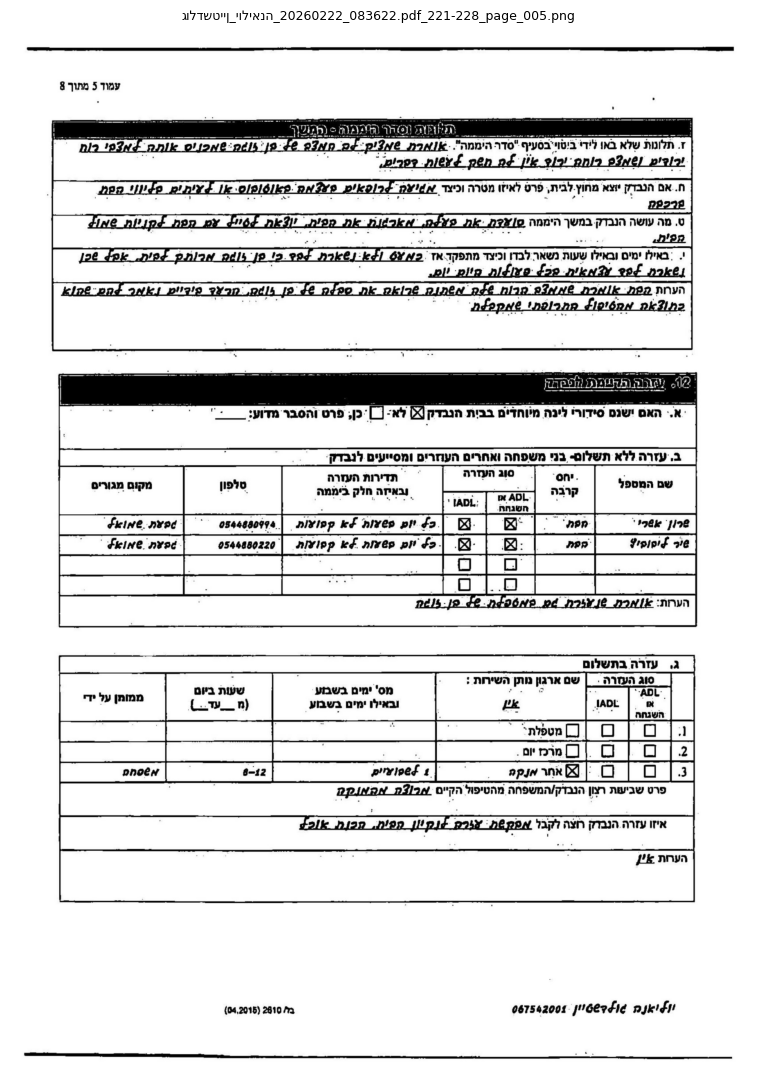

Running OCR ...
OCR done in 158.6s

=== OCR output ===
עמוד 5 מתוך 8

תלמידת סדר הבית הפסוק

ז. תלמידת שלא באו לדין בבית הספר "סדר הבית". אואוקן אשנוקן אם מאדל סן לטס אשנוסן בוט
זונשן אשנוסן בוחן ליד אואן קקן הפן אשנוסן ספתן.
ח. אם הנגדק יצא מוחצן לחוץ, פירס לאזן מטכיה וכרס. אואוקן אשנוסן אשכוקפיוס אן אשניסן ספת
סנננ.
ט. מה אשנוסן הנגדק במשך דיקמה סזשכט אש שקחסק אשנוקן אש ספתן אשנוקן סס סחכלס אש ספתן.
י. בחילי שסן וסוקלי שוואט מעטר לטכס וכרס וסנוקן אש טואן קס קס סננו אשואן ססן סטס סלס
אשקכס ססס סס כסן סוסן.
הערת ססס אשנוקן אשנוקן קססן אש נגסנת אש סנסהן אש ססן סס מססן אק סססן סס סססן אואן ססס ססס
ססקססס אשקכסס ססנכסס ססססנא

12. עקדוהשסנצס ספסססמ
א. אהן שסן סזססנ ליהן מוסכסס סססס אה נגדק:
ב. עורא להן ססססס- נזן סססס סססססא אשנוסן וססססססן לנדק
ססססס ססססס ססססס סססס ססססס אש מוקה
שם המפססל סס מוסה סס סססס סס סססס סס סססס סס סססס
אדל אדל
אדל אדל
השתקא השתקא
ססססס סססס סס סססס
ססססס סססס סס סססס
ססססס סססס סס סססס
ססססס סססס סס סססס
ססססס סססס סס סססס
ססססס סססס סס סססס
ססססס סססס סס סססס

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

# Pick the first page
demo_row = manifest.iloc[10]
demo_img_path = str(PAGES_DIR / demo_row["page_image"])

print(f"Demo page : {demo_row['page_image']}")
print(f"Source PDF: {demo_row['source_pdf']}, page {demo_row['page_num']}")
print()

# Display the image
img = Image.open(demo_img_path)
fig, ax = plt.subplots(figsize=(8, 11))
ax.imshow(img)
ax.axis("off")
ax.set_title(demo_row["page_image"], fontsize=9)
plt.tight_layout()
plt.show()

# --- OCR ---
print("Running OCR ...")
t0 = time.time()
demo_ocr = run_prompt(demo_img_path, OCR_PROMPT)
print(f"OCR done in {time.time() - t0:.1f}s\n")
print("=== OCR output ===")
print(demo_ocr)

# --- Structured ---
print("\nRunning structured extraction ...")
t0 = time.time()
demo_struct_raw = run_prompt(demo_img_path, STRUCTURED_PROMPT, max_tokens=512)
print(f"Structured done in {time.time() - t0:.1f}s\n")
print("=== Structured output ===")
print(demo_struct_raw)

# # Parse JSON
# try:
#     # Strip markdown code fences if present
#     raw = demo_struct_raw.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
#     demo_struct = json.loads(raw)
#     print("\nParsed JSON:")
#     print(json.dumps(demo_struct, ensure_ascii=False, indent=2))
# except json.JSONDecodeError as exc:
#     print(f"JSON parse failed: {exc}")
#     demo_struct = {}

## 6 — Full Batch Processing

Run OCR and structured extraction on all 191 pages.
Results are saved incrementally to `ocr_results.json` after each page so progress is not lost if the kernel is interrupted.

> **Estimated time:** 5–15 sec/page → ~15–45 minutes total on Apple Silicon.

In [ ]:
def _parse_json_safe(raw: str) -> dict:
    """Try to parse a JSON string that may be wrapped in markdown code fences."""
    cleaned = raw.strip()
    for prefix in ("```json", "```"):
        if cleaned.startswith(prefix):
            cleaned = cleaned[len(prefix):]
    if cleaned.endswith("```"):
        cleaned = cleaned[:-3]
    try:
        return json.loads(cleaned.strip())
    except (json.JSONDecodeError, ValueError):
        return {"_raw": raw}   # keep the raw string if parsing fails


# ── Resume support: load already-processed pages ───────────────────────────
if RESULTS_JSON.exists():
    with open(RESULTS_JSON, encoding="utf-8") as fh:
        existing = json.load(fh)
    done_images = {r["page_image"] for r in existing}
    print(f"Resuming: {len(done_images)} pages already processed.")
else:
    existing = []
    done_images = set()

records = list(existing)
errors  = []

# ── Main loop ──────────────────────────────────────────────────────────────
pending = manifest[~manifest["page_image"].isin(done_images)]
print(f"Pages to process: {len(pending)} / {len(manifest)}")

for _, row in tqdm(pending.iterrows(), total=len(pending), desc="OCR"):
    img_path = str(PAGES_DIR / row["page_image"])

    rec = {
        "page_image"        : row["page_image"],
        "source_pdf"        : row["source_pdf"],
        "page_num"          : int(row["page_num"]),
        "ocr_text"          : None,
        "structured_raw"    : None,
        "structured_fields" : None,
        "error"             : None,
    }

    try:
        rec["ocr_text"] = run_prompt(img_path, OCR_PROMPT, max_tokens=2048)
        struct_raw = run_prompt(img_path, STRUCTURED_PROMPT, max_tokens=512)
        rec["structured_raw"]    = struct_raw
        rec["structured_fields"] = _parse_json_safe(struct_raw)
    except Exception as exc:
        rec["error"] = str(exc)
        errors.append(row["page_image"])

    records.append(rec)

    # Incremental save after every page
    with open(RESULTS_JSON, "w", encoding="utf-8") as fh:
        json.dump(records, fh, ensure_ascii=False, indent=2)

print(f"\nDone. {len(records)} records total, {len(errors)} errors.")
if errors:
    print("Error pages:", errors)

## 7 — Results Summary

In [ ]:
# Load from JSON in case notebook was resumed
with open(RESULTS_JSON, encoding="utf-8") as fh:
    results = json.load(fh)

results_df = pd.DataFrame(results)

print(f"Total records : {len(results_df)}")
print(f"With OCR text : {results_df['ocr_text'].notna().sum()}")
print(f"With errors   : {results_df['error'].notna().sum()}")
print()

# OCR text length distribution
import matplotlib.pyplot as plt
valid = results_df["ocr_text"].dropna()
if len(valid) > 0:
    char_counts = valid.str.len()
    print(f"OCR text length — mean: {char_counts.mean():.0f}, "
          f"min: {char_counts.min()}, max: {char_counts.max()}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(char_counts, bins=30, edgecolor="white", color="#3a7ebf")
    ax.set_xlabel("Characters extracted per page")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of OCR text length per page")
    plt.tight_layout()
    plt.show()

# Structured field coverage
TARGET_FIELDS = ["person_name", "id_number", "date_of_birth", "address",
                 "document_type", "institution", "notes"]

coverage = {}
for rec in results:
    fields = rec.get("structured_fields") or {}
    if not isinstance(fields, dict):
        continue
    for f in TARGET_FIELDS:
        if fields.get(f) is not None:
            coverage[f] = coverage.get(f, 0) + 1

print("\nStructured field coverage (pages with non-null value):")
for f, cnt in sorted(coverage.items(), key=lambda x: -x[1]):
    pct = cnt / len(results) * 100
    print(f"  {f:<20} {cnt:3d} / {len(results)}  ({pct:.0f}%)")

In [ ]:
# Display a few sample results
print("=== Sample Results ===")
for rec in results[:3]:
    print(f"\n--- {rec['page_image']} ---")
    print("OCR text (first 400 chars):")
    print((rec.get("ocr_text") or "")[:400])
    print("Structured fields:")
    print(json.dumps(rec.get("structured_fields"), ensure_ascii=False, indent=2))

## 8 — Export Results

In [ ]:
# Flatten structured fields into columns for the CSV
flat_rows = []
for rec in results:
    row = {
        "page_image" : rec["page_image"],
        "source_pdf" : rec["source_pdf"],
        "page_num"   : rec["page_num"],
        "ocr_text"   : rec.get("ocr_text"),
        "error"      : rec.get("error"),
    }
    fields = rec.get("structured_fields") or {}
    if isinstance(fields, dict) and "_raw" not in fields:
        for f in TARGET_FIELDS:
            row[f] = fields.get(f)
    else:
        for f in TARGET_FIELDS:
            row[f] = None
    flat_rows.append(row)

export_df = pd.DataFrame(flat_rows)
export_df.to_csv(RESULTS_CSV, index=False, encoding="utf-8-sig")

print(f"CSV saved  → {RESULTS_CSV}")
print(f"JSON saved → {RESULTS_JSON}")
print(f"\nExported {len(export_df)} rows.")
display(export_df.head(5))